## Get data from https://fundamentus.com.br/detalhes.php?papel=<papel> and then store values on a python datashhet

# Read Position

In [ ]:
#conda activate base
import pandas as pd

# Lê o arquivo Excel
path = "/home/ponche/projects/ibox/b3/"
#fileName = "posicao-2025-12-06-15-13-40.xlsx"
fileName = "posicao-2026-03-03-08-12-09.xlsx"
file = path + fileName
print (file)
df_posicao = pd.read_excel(file, sheet_name='Fundo de Investimento', header=0, skiprows=0, nrows=300)
#df_posicao = pd.read_excel(file, sheet_name='Posição - Ações', header=0, skiprows=0, nrows=300)

#print(df_posicao.columns)
#print(df_posicao['Código de Negociação'])
df_posicao = df_posicao.dropna(subset=['Código de Negociação'])

df_posicao['Percentual'] = df_posicao['Valor Atualizado'] / df_posicao['Valor Atualizado'].sum()


/home/ponche/projects/ibox/b3/posicao-2026-02-26-16-36-16.xlsx


/home/ponche/anaconda3/lib/python3.12/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


# Create a function to get tiker data

In [13]:
import pandas as pd
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys
import time
import math

def converter_float(texto):
    texto = texto.replace(",", ".")
    if texto.endswith("%"):
        texto = texto[:-1]  # remove o símbolo de porcentagem
        if texto != 0:
            return float(texto) / 100
        else:
            return 0
    else:
        try:
            return float(texto)
        except ValueError:
            return 0

def get_ticker_data(ticker, df):
    # Create a new Chrome browser instance
    driver = webdriver.Chrome()
    

    tk = ticker['Código de Negociação']
    percentual = ticker['Percentual']
    # Go to the Python.org website
    driver.get(f"https://fundamentus.com.br/detalhes.php?papel={tk}")

    # Wait for the page to load (not recommended for robust scripts)
    time.sleep(.2)

    # Find the search bar element by its name attribute
    Segmento = driver.find_element(By.XPATH, "/html/body/div[1]/div[2]/table[1]/tbody/tr[4]/td[2]/span/a").text
    
    FFO_Yield = converter_float(driver.find_element(By.XPATH, "/html/body/div[1]/div[2]/table[3]/tbody/tr[7]/td[4]/span").text)
    Div_Yield = converter_float(driver.find_element(By.XPATH, "/html/body/div[1]/div[2]/table[3]/tbody/tr[3]/td[4]/span").text)
    p_por_vp = converter_float(driver.find_element(By.XPATH, "/html/body/div[1]/div[2]/table[3]/tbody/tr[4]/td[4]/span").text)
    	
    FFO_POR_Cota = converter_float(driver.find_element(By.XPATH, "/html/body/div[1]/div[2]/table[3]/tbody/tr[2]/td[6]/span").text)
    Dividendo_POR_cota = converter_float(driver.find_element(By.XPATH, "/html/body/div[1]/div[2]/table[3]/tbody/tr[3]/td[6]/span").text)
    VP_POR_Cota = converter_float(driver.find_element(By.XPATH, "/html/body/div[1]/div[2]/table[3]/tbody/tr[4]/td[6]/span").text)


    Receita_12m = converter_float(driver.find_element(By.XPATH, "/html/body/div[1]/div[2]/table[3]/tbody/tr[7]/td[4]/span").text)
    Venda_de_ativos_12m = converter_float(driver.find_element(By.XPATH, "/html/body/div[1]/div[2]/table[3]/tbody/tr[8]/td[4]/span").text)
    FFO_12m = converter_float(driver.find_element(By.XPATH, "/html/body/div[1]/div[2]/table[3]/tbody/tr[9]/td[4]/span").text)
    Rend_Distribuído_12m = converter_float(driver.find_element(By.XPATH, "/html/body/div[1]/div[2]/table[3]/tbody/tr[10]/td[4]/span").text)


    Receita_3m  = converter_float(driver.find_element(By.XPATH, "/html/body/div[1]/div[2]/table[3]/tbody/tr[7]/td[6]/span").text)
    Venda_de_ativos_3m  = converter_float(driver.find_element(By.XPATH, "/html/body/div[1]/div[2]/table[3]/tbody/tr[8]/td[6]/span").text)
    FFO_3m  = converter_float(driver.find_element(By.XPATH, "/html/body/div[1]/div[2]/table[3]/tbody/tr[9]/td[6]/span").text)
    Rend_Distribuído_3m  = converter_float(driver.find_element(By.XPATH, "/html/body/div[1]/div[2]/table[3]/tbody/tr[10]/td[6]/span").text)

    ativos = converter_float(driver.find_element(By.XPATH, "/html/body/div[1]/div[2]/table[3]/tbody/tr[12]/td[4]/span").text)
    patrimonio_liquido = converter_float(driver.find_element(By.XPATH, "/html/body/div[1]/div[2]/table[3]/tbody/tr[12]/td[6]/span").text)

    Qtd_imóveis = converter_float(driver.find_element(By.XPATH, "/html/body/div[1]/div[2]/table[5]/tbody/tr[2]/td[2]/span").text)
    Qtd_Unidades = converter_float(driver.find_element(By.XPATH, "/html/body/div[1]/div[2]/table[5]/tbody/tr[3]/td[2]/span").text)
    Imóveis_por_PL_do_FII = converter_float(driver.find_element(By.XPATH, "/html/body/div[1]/div[2]/table[5]/tbody/tr[4]/td[2]/span").text)

    area_m2 = converter_float(driver.find_element(By.XPATH, "/html/body/div[1]/div[2]/table[5]/tbody/tr[2]/td[4]/span").text)
    Aluguel_m2 = converter_float(driver.find_element(By.XPATH, "/html/body/div[1]/div[2]/table[5]/tbody/tr[3]/td[4]/span").text)
    Preco_do_m2 = converter_float(driver.find_element(By.XPATH, "/html/body/div[1]/div[2]/table[5]/tbody/tr[4]/td[4]/span").text)

    Cap_Rate = converter_float(driver.find_element(By.XPATH, "/html/body/div[1]/div[2]/table[5]/tbody/tr[2]/td[6]/span").text)
    Vacancia_Media = converter_float(driver.find_element(By.XPATH, "/html/body/div[1]/div[2]/table[5]/tbody/tr[3]/td[6]/span").text)


    lineData = {
        'TIKER': [tk], 'Segmento' : [Segmento], 'FFO_Yield': [FFO_Yield], 
        'Div_Yield': [Div_Yield], 'p_por_vp': [p_por_vp], 'PERCENTUAL' : [percentual],
        'FFO_POR_Cota': [FFO_POR_Cota], 'Dividendo_POR_cota': [Dividendo_POR_cota], 'VP_POR_Cota': [VP_POR_Cota],
        'Receita_12m': [Receita_12m], 'Venda_de_ativos_12m': [Venda_de_ativos_12m], 'FFO_12m': [FFO_12m], 'Rend_Distribuído_12m': [Rend_Distribuído_12m],
        'Receita_3m': [Receita_3m], 'Venda_de_ativos_3m': [Venda_de_ativos_3m], 'FFO_3m': [FFO_3m], 'Rend_Distribuído_3m': [Rend_Distribuído_3m],
        'ativos': [ativos], 'patrimonio_liquido': [patrimonio_liquido],
        'Qtd_imóveis': [Qtd_imóveis], 'Qtd_Unidades': [Qtd_Unidades], 'Imóveis_por_PL_do_FII': [Imóveis_por_PL_do_FII],
        'area_m2': [area_m2], 'Aluguel_m2': [Aluguel_m2], 'Preco_do_m2': [Preco_do_m2],
        'Cap_Rate': [Cap_Rate], 'Vacancia_Media': [Vacancia_Media]
    }

    libeDF = pd.DataFrame(lineData)
    
    # Append the new data to the existing dataframe
    df = pd.concat([df, libeDF], ignore_index=True)

    # Close the browser window
    driver.quit()

    return df

## Example usage:
#df = pd.DataFrame()
#df = get_ticker_data('PETR4', df)
#print(df)

In [14]:
#df = pd.DataFrame()  # Initialize an empty dataframe
#tk_dict = {'Código de Negociação': 'HGLG11', 'Percentual': 0}
#df = get_ticker_data(tk_dict, df)

# Loop function in all b3 tikers to create a DataFrame

In [15]:
fiis_tijolo_tickers = [
   "HGLG11", "XPML11", "BTLG11", "KNRI11", "XPLG11", 
   "VISC11", "TRXF11", "HGRU11", "PVBI11", "HGBS11", 
   "HSML11", "GGRC11", "BRCR11", "GARE11", "BRCO11", 
   "LVBI11", "HGRE11", "RBVA11", "TVRI11", "VILG11", 
   "HSLG11", "ALZR11", "BROF11", "GTWR11", "RBRL11", 
   "PATL11", "MALL11", "JSRE11", "RCRB11", "VINO11",
   "GGRC11", "MXRF11", "BTHF11", "PVBI11"
]

df = pd.DataFrame()  # Initialize an empty dataframe

print (time.strftime("%Y-%m-%d %H:%M:%S", time.gmtime()))

for tk in fiis_tijolo_tickers:
    tk_dict = {'Código de Negociação': tk, 'Percentual': 0}
    df = get_ticker_data(tk_dict, df)

print (time.strftime("%Y-%m-%d %H:%M:%S", time.gmtime()))

N = 0
for index, row in df_posicao.iterrows():
    N = N + 1
    print(row['Código de Negociação'])
    df = get_ticker_data(row, df)  # Call the function with the ticker symbol and dataframe
    if N > 1000:
        break


print(df)  # Print the resulting dataframe

2026-02-27 02:15:41
2026-02-27 02:18:04
BRCO11
BTAL11
BTLG11
CPTS11
HGLG11
KNSC11
LVBI11
RBRR11
TVRI11
VISC11
XPML11
AAZQ11
     TIKER        Segmento  FFO_Yield  Div_Yield  p_por_vp  PERCENTUAL  \
0   HGLG11  Multicategoria          0      0.083      0.95    0.000000   
1   XPML11       Shoppings          0      0.098      1.00    0.000000   
2   BTLG11  Multicategoria          0      0.091      1.00    0.000000   
3   KNRI11  Multicategoria          0      0.072      1.01    0.000000   
4   XPLG11       Logística          0      0.096      0.97    0.000000   
5   VISC11       Shoppings          0      0.086      0.94    0.000000   
6   TRXF11  Multicategoria          0      0.126      0.92    0.000000   
7   HGRU11          Outros          0      0.094      1.01    0.000000   
8   PVBI11     Escritórios          0      0.073      0.72    0.000000   
9   HGBS11       Shoppings          0      0.090      0.99    0.000000   
10  HSML11       Shoppings          0      0.085      0.91    

# Group repeated tiker and sumarize percentage

In [16]:
# Agrupar os TIKERs repetidos e somar o percentual, mantendo todas as colunas
df_grouped = df.groupby('TIKER', as_index=False).agg({
    col: 'first' if col not in ['PERCENTUAL'] else 'sum' for col in df.columns
})



print(df_grouped)


     TIKER        Segmento  FFO_Yield  Div_Yield  p_por_vp  PERCENTUAL  \
0   AAZQ11          Outros          0      0.078      0.97    0.003396   
1   ALZR11  Multicategoria          0      0.092      1.01    0.000000   
2   BRCO11       Logística          0      0.087      1.04    0.024207   
3   BRCR11  Multicategoria          0      0.103      0.57    0.000000   
4   BROF11  Multicategoria          0      0.102      0.57    0.000000   
5   BTAL11       Logística          0      0.118      0.78    0.091812   
6   BTHF11          Outros          0      0.117      0.94    0.000000   
7   BTLG11  Multicategoria          0      0.091      1.00    0.083101   
8   CPTS11          Outros          0      0.128      0.87    0.048516   
9   GARE11  Multicategoria          0      0.115      0.90    0.000000   
10  GGRC11  Multicategoria          0      0.116      0.92    0.000000   
11  GTWR11     Escritórios          0      0.122      0.84    0.000000   
12  HGBS11       Shoppings          0 

# Send dataframe to csv file

In [17]:
#df.to_excel('C:/GitProjects/training/tikers.xlsx', index=False)
#df.to_csv('/home/ponche/projects/ibox/results/tikers.csv')
df_grouped.to_csv('/home/ponche/projects/ibox/results/fii_tikers_grouped.csv')

# Checklist Simples para Avaliar a Necessidade de Vender
* __Verificação de Valoração__ – A ação está significativamente sobrevalorizada em relação à sua própria história e aos pares?
* __Revisão de Lucros/Rentabilidade__ – EPS, margens ou ROE estão caindo sem explicação?
* __Análise do Balanço__ – Alavancagem está subindo enquanto o fluxo de caixa enfraquece?
* __Perspectiva de Crescimento__ – Guidance e previsões de analistas foram cortados repetidamente?
* __Saúde do Dividendo__ (se for o caso) – O payout ratio é insustentável?
* __Alertas Qualitativos__ – Existem questões de governança, mudanças de gestão ou riscos setoriais graves?


# Principais indicadores de alavancagem
|Indicador	|Fórmula (versão simplificada)	|O que mede	Faixa “normal” (orientativa)|
|---|---|---|
|Debt‑to‑Equity (Divida / Patrimonio) |	Total Dívida ÷ Patrimônio Líquido	|Relação entre capital de terceiros e capital próprio.	< 1,0 para a maioria das empresas; > 2,0 costuma ser sinale alta alavancagem (varia muito por setor).|
|Debt‑to‑EBITDA	|Total Dívida ÷ EBITDA	|Quantos anos de geração operacional de caixa seriam necessários para pagar a dívida, se nada mudasse.	< 3 × é considerado saudável na maioria dos setores; > 4‑5 × pode indicar risco.|
| Net‑Debt‑to‑EBITDA	|( Dívida bruta − Caixa e Equivalentes) ÷ EBITDA	|Mesmo que acima, mas já desconta a caixa que pode ser usada para amortizar a dívida.	< 2,5 × é confortável; > 4 × – alerta.|
| Interest Coverage (Cobertura de Juros)	|EBIT ÷ Despesa de Juros	| Capacidade de pagar os juros apenas com o lucro operacional.	> 3‑4 × é bom; < 1,5 × indica dificuldade. |
| Debt‑to‑Capital	| Total Dívida ÷ (Total Dívida + Patrimônio Líquido)	| Percentual do capital total que provém de dívida. |
|---|---|---|


## Chart of alocation per sector

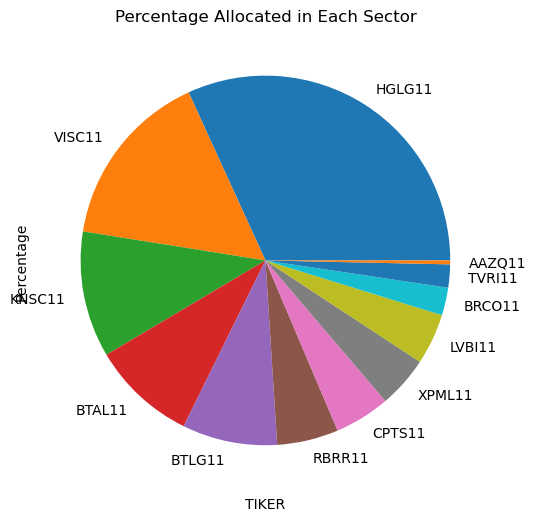

In [18]:


#create a chart using df dataframe to show the percentage alocated in each Tiker
import matplotlib.pyplot as plt
#print(df)

sector_data = df_grouped.groupby('TIKER')['PERCENTUAL'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sector_data.plot(kind='pie')
plt.title('Percentage Allocated in Each Sector')
plt.xlabel('TIKER')
plt.ylabel('Percentage')
plt.show()




# Call Gemini

In [ ]:

import google.generativeai as genai
from google import genai
import os
from dotenv import load_dotenv

load_dotenv()


genai.configure(api_key = os.getenv('GEMINI_API_KEY'))

def analyze_portfolio(file_path):
    # 1. Read the CSV file
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            csv_content = f.read()
    except FileNotFoundError:
        return "Error: CSV file not found."
    
    ## 2. Read the HTML structure file
    #html_file_path = '/home/ponche/projects/ibox/reports/KimiReport.html'
    #try:
    #    with open(html_file_path, 'r', encoding='utf-8') as f:
    #        html_content = f.read()
    #except FileNotFoundError:
    #    return "Error: Html file not found."
    

    # 3. Define the analysis prompt
    
  
    #- Use Tailwind CSS classes for styling.
    #- Show top 10 current alocations and percentage of allocation for summary of the top 10.
    
    prompt = f"""
    You are an expert financial analyst AI tasked with creating a portfolio review for fundos imobiliarios.
    I am providing you with my stock portfolio of fundos imobiliarios data in CSV format. The 'PERCENTUAL' column represents the allocation percentage.

    Your task is to analyze this data and generate a comprehensive investment report in HTML format.

    **Crucially, you must prioritize your analysis on the stocks with the highest allocation percentages.**

    Here are the analysis criteria:

    1.  **High-Risk Fundos imobiliarios to Consider Selling:** 
    2.  **Stocks to Buy/Keep for Dividends:** 
    3.  **Stocks with High Growth Potential:**

    **Output Requirements:**
    - Generate the complete, raw HTML code for this report.
    - Output the result in a single code block.
    - Do not include conversational text; provide only the HTML and CSS.
    - HTML report should should use almost all space on a wide monitor, using nigh like format.
    - Create three distinct sections: High-Risk, Dividends, Growth. For each section, order by the impact of the advise.
    - Prioritize risk analysis on the top allocated stocks.
    - Each section must have a table with columns: "Ticker", "Segmento", "Current Percentage" ,"Current Price", "Key Metric", "Justification", "Suggested Allocation".
    - In the "Ticker" column, hyperlink the symbol to MSNFundamentus: https://www.fundamentus.com.br/detalhes.php?papel=TICKER
    - Provide concrete "Suggested Allocation" advice.
    

    Here is the CSV data:
    - csv file decimal separator is dot(.) and thousands separator is comma(,).
    ---
    {csv_content}
    ---
    """

    # 3. Call the Gemini API
    print(f"Analyzing {file_path} with Gemini...")
    model = genai.GenerativeModel('gemini-flash-latest')
    #model = genai.GenerativeModel('gemini-2.5-flash')
    #model = genai.GenerativeModel('gemini-2.5-pro')
    
    
    try:
        response = model.generate_content(prompt)
        return response.text
    except Exception as e:
        return f"Error analyzing portfolio: {str(e)}"

if __name__ == "__main__":
    # Replace with your CSV file path
    csv_file = "/home/ponche/projects/ibox/results/fii_tikers_grouped.csv" 
    
    # Generate the report
    html_report = analyze_portfolio(csv_file)
    
    # Clean up markdown code blocks if present
    if html_report.startswith('```html'):
        html_report = html_report[7:-3].strip()
    elif html_report.startswith('```'):
        html_report = html_report[3:-3].strip()

    # Save to file
    output_file = '/home/ponche/projects/ibox/reports/report.html'
    with open(output_file, "w", encoding='utf-8') as f:
        # Wrap in a basic HTML structure for viewing
        full_html = f"""
        <!DOCTYPE html>
        <html lang="en">
        <head>
            <meta charset="UTF-8">
            <title>Portfolio Analysis</title>
            <script src="https://cdn.tailwindcss.com"></script>
        </head>
        <body class="bg-gray-100 p-8">
            <div class="max-w-4xl mx-auto">
                {html_report}
            </div>
        </body>
        </html>
        """
        f.write(full_html)
    
    print(f"Analysis complete! Report saved to {output_file}")
    




Analyzing /home/ponche/projects/ibox/results/fii_tikers_grouped.csv with Gemini...
Analysis complete! Report saved to /home/ponche/projects/ibox/reports/report.html


# Display report here as well

In [20]:
from IPython.display import display, HTML
display(HTML(html_report))


Ticker,Segmento,Current %,Current Price,Key Metric,Justification,Suggested Allocation
BTAL11,Logística,9.18%,R$ 90.45,P/VP: 0.78,Significant allocation (9%) for a fund trading at a 22% discount. The deep discount in the logistics sector often signals credit risk or specific tenant issues. FFO/cota is high but price action remains weak.,Reduce to 4.0%
VINO11,Multicategoria,0.00%*,R$ 5.54,P/VP: 0.56,"Extreme discount. While usually a buy signal, the office/multicategory sector faces structural leverage issues. High risk of capital erosion despite current yield perception.",Avoid / Sell Remaining
JSRE11,Multicategoria,0.00%*,R$ 66.36,P/VP: 0.64,"Consistent underperformance in NAV. Although the discount is massive, the vacancy management and financial costs are concerning compared to peers.",Exit Position
Ticker,Segmento,Current %,Current Price,Key Metric,Justification,Suggested Allocation
KNSC11,Multicategoria,11.04%,R$ 9.14,DY: 12.3%,Solid high-yield credit fund. Maintaining a P/VP of 1.04 suggests market confidence. Excellent risk-adjusted returns for the income portion of the portfolio.,Keep / Reinvest
CPTS11,Outros,4.85%,R$ 8.04,DY: 12.8%,Paper fund trading at 0.87 P/VP. Offers double-digit dividends with capital protection margin due to the 13% discount on its asset base.,Increase to 7.0%
TRXF11,Multicategoria,0.00%*,R$ 93.07,DY: 12.6%,Hybrid strategy with retail exposure and long-term atypical contracts. High historical dividend stability even during volatile cycles.,Add to 5.0%
Ticker,Segmento,Current %,Current Price,Key Metric,Justification,Suggested Allocation
HGLG11,Multicategoria,31.82%,R$ 158.09,P/VP: 0.95,"The flagship of logistics. Currently trading below its intrinsic value (P/VP 0.95). As interest rates stabilize, the convergence to NAV offers clear capital upside.",Trim to 20% (Diversification)
VISC11,Shoppings,15.67%,R$ 110.97,P/VP: 0.94,Mall recovery cycle is ongoing. Trading at a 6% discount with high-quality assets. Large portfolio scale allows for active management and asset recycling gains.,Keep Core Position
